# Multiple Linear Regression

In the previous notebook, we looked at **Simple Linear Regression**, where we predicted a target variable using only **one** feature (e.g., predicting Test Scores using Study Hours).

However, the real world is rarely that simple. A student's test score depends on study hours, hours of sleep, attendance rate, and many other factors.

When we use **two or more features** to predict a target, it is called **Multiple Linear Regression**.

### The Equation
In Simple Linear Regression, we had a line: 
$$Y = \beta_0 + \beta_1 x_1$$

In Multiple Linear Regression, we expand that to multiple dimensions:
$$Y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \beta_3 x_3 + \dots + \beta_n x_n$$

Instead of drawing a line in 2D space, we are now fitting a **plane** (in 3D) or a **hyperplane** (in 4D+) through our data!

Let's implement this!

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## 1. The Data

Instead of generating fake data by hand, we will use Scikit-Learn's incredibly useful `make_regression` function. This generates a random regression dataset for us, allowing us to specify exactly how many features we want.

In [17]:
# Generate a dataset with 500 samples, 3 features, and some noise
X, y = make_regression(n_samples=500, n_features=3, noise=15.0, random_state=42)

# Let's convert it to a Pandas DataFrame so it is easier to understand
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2', 'Feature_3'])
df['Target_Y'] = y

display(df.head())
print(f"Dataset shape: {df.shape}")

,Feature_1,Feature_2,Feature_3,Target_Y
0,-0.825497,-0.321386,0.412931,-33.622101
1,-1.146345,0.302635,-0.754276,-61.295168
2,-1.377669,-0.937825,0.515035,-90.528888
3,0.599929,1.530751,1.218762,166.911150
4,0.638730,-1.143005,1.633432,20.971902


Dataset shape: (500, 4)


### Visualizing the Original Data
We have 3 distinct features. Let's plot each of the features independently against our `Target_Y` so you can visually see how each feature contributes to the final result.

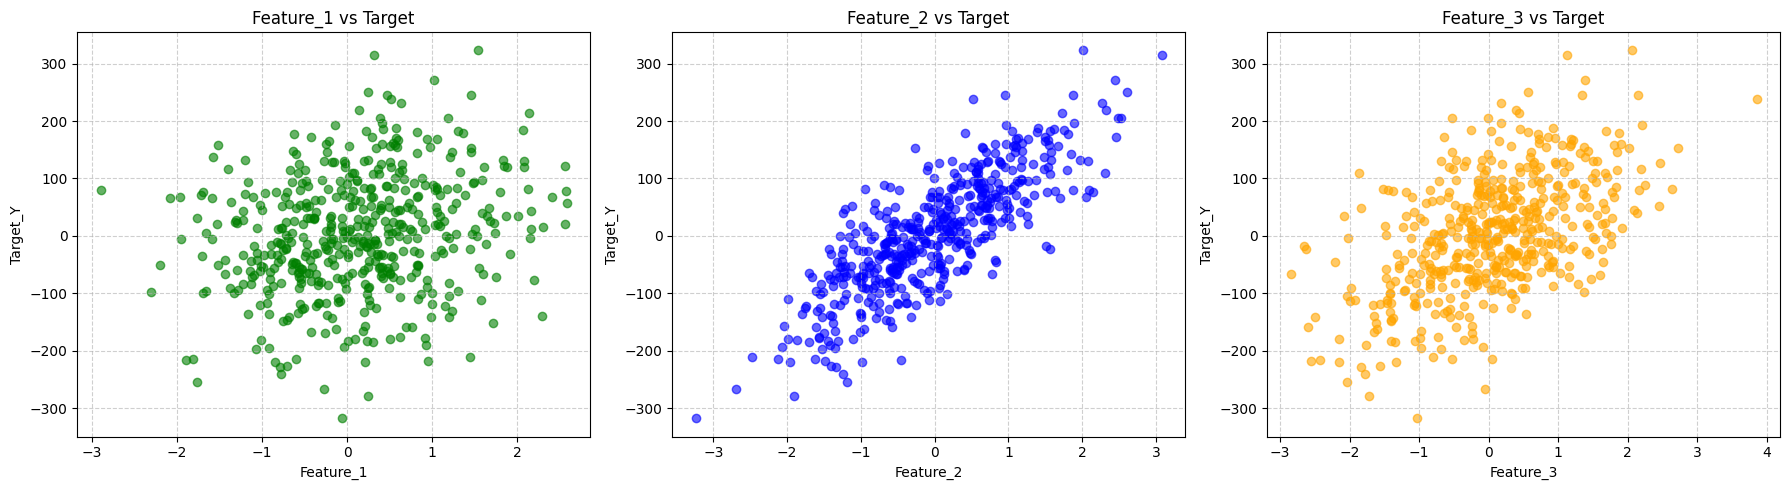

In [18]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

colors = ['green', 'blue', 'orange']
for i in range(3):
    feature_name = f'Feature_{i+1}'
    axs[i].scatter(df[feature_name], df['Target_Y'], color=colors[i], alpha=0.6)
    axs[i].set_xlabel(feature_name)
    axs[i].set_ylabel('Target_Y')
    axs[i].set_title(f'{feature_name} vs Target')
    axs[i].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

Notice how each feature has a linear correlation with the Target! Some might be strongly correlated, while others are grouped closer to zero. Our Multiple Linear Regression model will learn to combine all 3 of these slopes together.

## 2. Train / Test Split
We need to evaluate our model on unseen data to ensure it isn't just memorizing the training set.

In [19]:
# We already have our variables 'X' (the 3 features) and 'y' (the target) from earlier.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (400, 3)
Testing set shape: (100, 3)


## 3. Train the Model

Here is the beauty of Scikit-Learn: **The code is exactly the same as Simple Linear Regression.** 
Scikit-Learn automatically detects that your `X_train` has 3 columns instead of 1, and handles the advanced matrix math behind the scenes.

In [20]:
# Initialize the model
model = LinearRegression()

# Fit the model
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


### Understanding Multiple Coefficients

In Simple Linear regression, we had one slope (weight) and one intercept (bias).

Because we now have 3 features, our model learned **3 separate weights**, one for each feature. This tells us how important each feature is for predicting the final target.

In [13]:
print(f"The Intercept (b0) is: {model.intercept_:.2f}\n")

print("The Weights (Slopes) are:")
print(f"Feature 1 (b1): {model.coef_[0]:.2f}")
print(f"Feature 2 (b2): {model.coef_[1]:.2f}")
print(f"Feature 3 (b3): {model.coef_[2]:.2f}\n")

print("Our equation is:")
print(f"Y = {model.intercept_:.2f} + ({model.coef_[0]:.2f} * X1) + ({model.coef_[1]:.2f} * X2) + ({model.coef_[2]:.2f} * X3)")

The Intercept (b0) is: -0.14

The Weights (Slopes) are:
Feature 1 (b1): 26.56
Feature 2 (b2): 83.56
Feature 3 (b3): 50.13

Our equation is:
Y = -0.14 + (26.56 * X1) + (83.56 * X2) + (50.13 * X3)


## 4. Make Predictions and Evaluate

Now we pass our isolated 20% of testing data (`X_test`) into the model.

In [14]:
predictions = model.predict(X_test)

mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-Squared Score (R2): {r2:.2f}")

Mean Squared Error (MSE): 233.81
R-Squared Score (R2): 0.98


### Why can't we easily plot this?

With Simple Linear Regression, it was very easy to visualize a scatter plot with a red line running through it.

Because we have 3 features + 1 target, our data technically exists in **4-Dimensional Space**. Humans cannot visualize 4D space! 

However, a great alternative way to visualize Multiple Linear Regression is to plot the **Actual Values vs. the Predicted Values**. If our model is perfectly accurate, the dots should form a straight, 45-degree diagonal line.

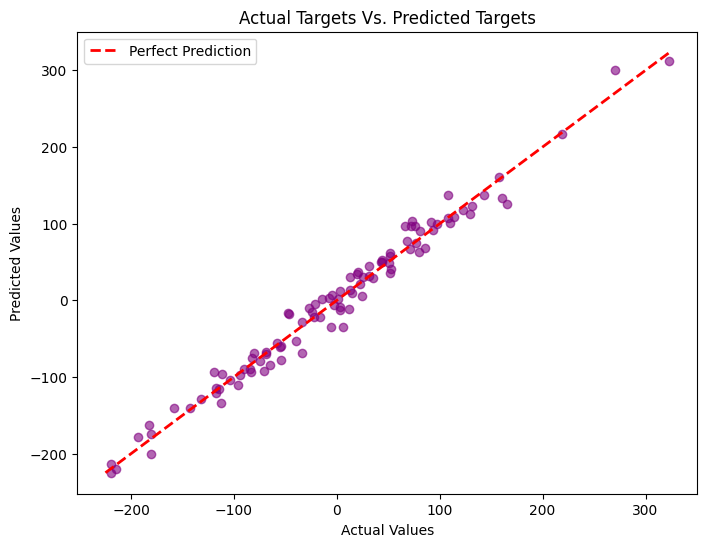

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, color="purple", alpha=0.6)

# Draw the perfect "45-degree" diagonal line
max_val = max(y_test.max(), predictions.max())
min_val = min(y_test.min(), predictions.min())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", linewidth=2, label="Perfect Prediction")

plt.title("Actual Targets Vs. Predicted Targets")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.legend()
plt.show()